In [16]:
from pathlib import Path
from lips.benchmark.airfransBenchmark import AirfRANSBenchmark
from lips import get_root_path
import os
import numpy as np
import torch
import pandas as pd
import random
import matplotlib.pyplot as plt
from bump_airfoil_dataset import BumpComboAirfoilDataset

random.seed(32)

LIPS_PATH = get_root_path()
LOG_PATH = LIPS_PATH + "lips_logs.log"
BENCHMARK_NAME = "DEFAULT"

BASE_DIR = Path.cwd().parent
DIRECTORY_NAME = os.path.join(BASE_DIR, 'airfrans_data/Dataset')
BENCH_CONFIG_PATH = os.path.join(BASE_DIR, 'src/confAirfoil.ini')

print(BASE_DIR)
print(BENCH_CONFIG_PATH)

/Users/jay/Desktop/MIT/DIG/ob-gnn_code/ML4CFD-Offset-based-Graph-Convolution
/Users/jay/Desktop/MIT/DIG/ob-gnn_code/ML4CFD-Offset-based-Graph-Convolution/src/confAirfoil.ini


# Saving Per-Simulation MSE

In [19]:
# load benchmark
benchmark=AirfRANSBenchmark(benchmark_path = DIRECTORY_NAME,
                            config_path = BENCH_CONFIG_PATH,
                            benchmark_name = BENCHMARK_NAME,
                            log_path = LOG_PATH)
print(vars(benchmark))
benchmark.load(path=DIRECTORY_NAME)

{'benchmark_name': 'DEFAULT', 'benchmark_path': '/Users/jay/Desktop/MIT/DIG/ob-gnn_code/ML4CFD-Offset-based-Graph-Convolution/airfrans_data/Dataset', 'path_datasets': '/Users/jay/Desktop/MIT/DIG/ob-gnn_code/ML4CFD-Offset-based-Graph-Convolution/airfrans_data/Dataset/DEFAULT', 'config': <lips.config.configmanager.ConfigManager object at 0x2af15c790>, 'dataset': None, 'observations': {}, 'predictions': {}, 'augmented_simulator': None, 'log_path': '/opt/anaconda3/envs/ob-gnn/lib/python3.10/site-packages/lips/lips_logs.log', 'logger': <Logger Benchmark (INFO)>, 'is_loaded': False, 'evaluation': <lips.evaluation.airfrans_evaluation.AirfRANSEvaluation object at 0x2b85402b0>, 'training_simulator': None, 'test_simulator': None, 'train_dataset': <lips.dataset.airfransDataSet.AirfRANSDataSet object at 0x2af15c1f0>, '_test_dataset': <lips.dataset.airfransDataSet.AirfRANSDataSet object at 0x2af15ec50>, '_test_ood_dataset': <lips.dataset.airfransDataSet.AirfRANSDataSet object at 0x2af15f550>, 'ml_n

Loading dataset (task: reynolds, split: test): 100%|██████████| 496/496 [01:16<00:00,  6.48it/s]


In [20]:
from bump_airfoil_dataset import BumpComboAirfoilDataset

def compute_global_stats(dataset, target_fields):
    stats = {}
    for key in target_fields:
        data = dataset.data[key]  # shape (total_nodes,)
        stats[key] = {
            'mean': np.mean(data),
            'std': np.std(data)
        }
    return stats

def make_mse_table(dataset, pred_dir, target_fields):
    # sim_id, MSE x-vel, MSE y-vel, MSE pres, MSE turb
    mse_rows = []
    stats = compute_global_stats(dataset, target_fields)
    p = 0
    for sim_name, size in dataset.extra_data['simulation_names']:
        size = int(size)

        pred_data = torch.load(pred_dir/f'pred_{sim_name}.pt')
        mse_row = [sim_name]
        for i, field in enumerate(target_fields):
            # raw mse
            field_mse = np.mean((dataset.data[field][p:p+size] - np.array(pred_data[:,i]).flatten())**2)
            mse_row.append(field_mse)
            # normalized mse = mse / std**2
            normalized_field_mse = field_mse / (stats[field]['std']**2)
            mse_row.append(normalized_field_mse)
       
        mse_rows.append(mse_row)
        p += size
    
    df = pd.DataFrame(mse_rows, columns=['sim_name','x-vel_mse','x-vel_mse_norm',
                                         'y-vel_mse','y-vel_mse_norm',
                                         'pressure_mse','pressure_mse_norm',
                                         'turbulent_viscosity_mse','turbulent_viscosity_mse_norm'])
    return df

def save_mse_table(model_version, split, benchmark, base_dir):
    pred_dir = base_dir /'predictions'/model_version/split
    mse_csv_path = base_dir / 'evaluation' / f'{model_version}_{split}_mse.csv'

    if split == 'test':
        dataset =  benchmark._test_dataset
    elif split == 'test_ood':
        dataset =  benchmark._test_ood_dataset
    elif split == 'test_bump':
        attr_names = benchmark.train_dataset._attr_names
        bumped_dir = base_dir / 'airfrans_data'/'bumped_dataset'
        dataset = BumpComboAirfoilDataset('test',
                                            dict(), 
                                            dict(),
                                            attr_names,
                                            bumped_dir=bumped_dir,
                                            split='test',
                                            split_csv=base_dir / 'airfrans_data' / 'bumped_dataset_split.csv')
    
    target_fields = ['x-velocity', 'y-velocity', 'pressure', 'turbulent_viscosity']
    # make table
    df = make_mse_table(dataset, pred_dir, target_fields)
    # save table
    df.to_csv(mse_csv_path)

In [22]:
# save full mse table
model_version = 'B'
split = 'test_bump'
save_mse_table(model_version, split, benchmark, BASE_DIR)

# for split in ['test','test_ood','test_bump']:
#     save_mse_table(model_version, split, benchmark, BASE_DIR)

# Save Processed Dataset

In [ ]:
from bump_airfoil_dataset import BumpComboAirfoilDataset
from main import AugmentedSimulator

attr_names = ('x-position', 'y-position', 'x-inlet_velocity', 'y-inlet_velocity', 'distance_function', 'x-normals', 'y-normals', 'x-velocity', 'y-velocity', 'pressure', 'turbulent_viscosity')
bumped_dir = BASE_DIR / 'airfrans_data' / 'bumped_dataset'

dataset = BumpComboAirfoilDataset('val',
                                        dict(), 
                                        dict(),
                                        attr_names,
                                        bumped_dir=bumped_dir,
                                        split='val',
                                        split_csv=BASE_DIR / 'airfrans_data' / 'bumped_dataset_split.csv')
print(dataset.extra_data['simulation_names'].shape)

sim = AugmentedSimulator(benchmark)
data = sim.process_dataset(dataset, training=False)

In [ ]:
tmp_path = BASE_DIR / 'processed_val_bump.pt'
torch.save(data, tmp_path)

# Get Summary MSE

In [23]:
# get overall mse for a given split
def get_full_mse_table(model_version, split, base_dir):
    mse_csv_path = base_dir / 'evaluation' / f'{model_version}_{split}_mse.csv'
    df = pd.read_csv(mse_csv_path)
    return df

def get_summary_mse(model_version, split, base_dir):
    mse_df = get_full_mse_table(model_version, split, base_dir)
    print(f'===== OB-GNN-{model_version} {split} MSE Stats =====')
    print('--- MSE raw ---')
    print(mse_df[['x-vel_mse','y-vel_mse','pressure_mse','turbulent_viscosity_mse']].mean(axis=0))
    print('\n--- MSE normalized ---')
    print(mse_df[['x-vel_mse_norm','y-vel_mse_norm','pressure_mse_norm','turbulent_viscosity_mse_norm']].mean(axis=0))
    return mse_df[['x-vel_mse_norm','y-vel_mse_norm','pressure_mse_norm','turbulent_viscosity_mse_norm']].mean(axis=0)

def add_rmse(df):
    df['x-vel_rmse'] = df['x-vel_mse'] ** 0.5
    df['y-vel_rmse'] = df['y-vel_mse'] ** 0.5
    df['pressure_rmse'] = df['pressure_mse'] ** 0.5
    df['turbulent_viscosity_rmse'] = df['turbulent_viscosity_mse'] ** 0.5
    return df

get_summary_mse('O','test_bump', BASE_DIR)

===== OB-GNN-O test_bump MSE Stats =====
--- MSE raw ---
x-vel_mse                     66.360179
y-vel_mse                      7.336208
pressure_mse               78073.614000
turbulent_viscosity_mse        0.000003
dtype: float64

--- MSE normalized ---
x-vel_mse_norm                  0.053764
y-vel_mse_norm                  0.008576
pressure_mse_norm               0.021284
turbulent_viscosity_mse_norm    0.497434
dtype: float64


x-vel_mse_norm                  0.053764
y-vel_mse_norm                  0.008576
pressure_mse_norm               0.021284
turbulent_viscosity_mse_norm    0.497434
dtype: float64

In [24]:
df = get_summary_mse('B','test_bump', BASE_DIR)
display(df)

===== OB-GNN-B test_bump MSE Stats =====
--- MSE raw ---
x-vel_mse                     39.573999
y-vel_mse                      2.551228
pressure_mse               30653.271212
turbulent_viscosity_mse        0.000002
dtype: float64

--- MSE normalized ---
x-vel_mse_norm                  0.032062
y-vel_mse_norm                  0.002982
pressure_mse_norm               0.008356
turbulent_viscosity_mse_norm    0.401850
dtype: float64


x-vel_mse_norm                  0.032062
y-vel_mse_norm                  0.002982
pressure_mse_norm               0.008356
turbulent_viscosity_mse_norm    0.401850
dtype: float64

In [37]:
df = get_full_mse_table('B', 'test_bump', BASE_DIR)
cols = ['x-vel_mse_norm', 'y-vel_mse_norm', 'pressure_mse_norm', 'turbulent_viscosity_mse_norm']
df['overall_norm'] = (df['x-vel_mse_norm'] + df['y-vel_mse_norm'] + df['pressure_mse_norm'] + df['turbulent_viscosity_mse_norm'])/4.0
display(df[['sim_name','overall_norm']+cols].sort_values(by='overall_norm', ascending=False))

,sim_name,overall_norm,x-vel_mse_norm,y-vel_mse_norm,pressure_mse_norm,turbulent_viscosity_mse_norm
89,bump_274-11-0.007_87.639_5.000_0_0_12,3.271201,0.341798,0.054274,0.190481,12.498249
35,bump_242-11-0.007_87.639_5.000_0_0_12,0.692733,0.161450,0.010367,0.043311,2.555804
34,bump_200-11-0.007_87.639_5.000_0_0_12,0.673511,0.113212,0.006193,0.029219,2.545421
46,bump_242-22-0.007_87.639_5.000_0_0_12,0.537902,0.072724,0.005173,0.022335,2.051377
73,bump_58-10-0.007_87.639_5.000_0_0_12,0.400237,0.082773,0.006297,0.016227,1.495651
...,...,...,...,...,...,...
41,bump_143-18-0.003_87.639_5.000_0_0_12,0.006127,0.007390,0.001396,0.003248,0.012472
44,bump_128-17-0.002_87.639_5.000_0_0_12,0.005216,0.005922,0.001240,0.001920,0.011782
62,bump_146-13-0.002_87.639_5.000_0_0_12,0.005145,0.006824,0.001253,0.002262,0.010242
52,bump_98-16-0.001_87.639_5.000_0_0_12,0.004007,0.005228,0.001261,0.001669,0.007869


In [27]:
overall_df = None

for model_version in ['O','A','B','C']:
    for split in ['test','test_ood','test_bump']:
        df = get_full_mse_table(model_version,split,BASE_DIR)
        sum_df = df[['x-vel_mse_norm','y-vel_mse_norm','pressure_mse_norm','turbulent_viscosity_mse_norm']].mean(axis=0).to_frame().T
        sum_df['model'] = f'OB-GNN-{model_version}'
        sum_df['split'] = split
        sum_df = sum_df[['model','split','x-vel_mse_norm','y-vel_mse_norm','pressure_mse_norm','turbulent_viscosity_mse_norm']]
        if overall_df is None:
            overall_df = sum_df
        else:
            overall_df = pd.concat((overall_df, sum_df))

display(overall_df.sort_values(by=['split']))

,model,split,x-vel_mse_norm,y-vel_mse_norm,pressure_mse_norm,turbulent_viscosity_mse_norm
0,OB-GNN-O,test,0.002682,0.001408,0.003046,0.033240
0,OB-GNN-A,test,0.004808,0.003930,0.007089,0.037580
0,OB-GNN-B,test,0.004301,0.001756,0.005872,0.045934
0,OB-GNN-C,test,0.004537,0.002569,0.005111,0.070002
0,OB-GNN-O,test_bump,0.095916,0.014108,0.158049,0.806728
0,OB-GNN-A,test_bump,0.033761,0.003647,0.009514,0.401739
0,OB-GNN-B,test_bump,0.033847,0.003435,0.009188,0.417305
0,OB-GNN-C,test_bump,0.033176,0.004132,0.009181,0.592225
0,OB-GNN-O,test_ood,0.007587,0.002894,0.007993,0.052966
0,OB-GNN-A,test_ood,0.009279,0.006895,0.013151,0.058950


# Select Best Epoch Checkpoint

In [169]:
def get_best_summary_mse(model_ver, norm=True):
    df = pd.read_csv(BASE_DIR/f'evaluation/{model_ver}_best_summary_mse.csv')
    df = add_rmse(df)

    df['overall_mse_norm'] = (df['x-vel_mse_norm']+df['y-vel_mse_norm']+df['pressure_mse_norm']+df['turbulent_viscosity_mse_norm'])/4.0
    if norm:
        return (df[['model_version', 'split','overall_mse_norm','x-vel_mse_norm','y-vel_mse_norm','pressure_mse_norm','turbulent_viscosity_mse_norm']].sort_values(by=['split','overall_mse_norm']))
    else:
        return (df[['model_version','split','x-vel_rmse','y-vel_rmse','pressure_rmse','turbulent_viscosity_rmse']])

field_df = get_best_summary_mse('A')
field_df = field_df[field_df['split']=='test_bump']
display(field_df)

,model_version,split,overall_mse_norm,x-vel_mse_norm,y-vel_mse_norm,pressure_mse_norm,turbulent_viscosity_mse_norm
8,A_v2_ep0026,test_bump,0.107914,0.032131,0.003020,0.008383,0.388122
5,A_v1_ep0018,test_bump,0.108625,0.032517,0.003138,0.008560,0.390284
9,A_v1_ep0012,test_bump,0.108821,0.032283,0.003295,0.009199,0.390508
11,A_v2_ep0015,test_bump,0.108964,0.032656,0.003183,0.008836,0.391182
10,A_v2_ep0012,test_bump,0.109132,0.032271,0.003313,0.009217,0.391728
2,A_v1_ep0011,test_bump,0.112174,0.032529,0.003559,0.009158,0.403449


## Get Mean + Std of Multiple Runs

In [211]:
df = pd.read_csv(BASE_DIR / 'evaluation/O_summary_mse.csv')
df = add_rmse(df)
df['overall'] =( df['x-vel_mse_norm'] + df['y-vel_mse_norm'] + df['pressure_mse_norm'] + df['turbulent_viscosity_mse_norm'] ) / 4.0
df.drop(columns=['model_version','x-vel_mse','y-vel_mse','pressure_mse','turbulent_viscosity_mse'], inplace=True)

result = df.groupby('split').agg(['mean', 'std'])
format_dict = {col: "{:.4f}" for col in result.columns[:-2]}
display(result)

x-vel_mse_norm           y-vel_mse_norm           pressure_mse_norm  \
                    mean       std           mean       std              mean   
split                                                                           
test            0.002738  0.000332       0.001638  0.000199          0.003450   
test_bump       0.053613  0.000168       0.009116  0.000898          0.021902   
test_ood        0.007095  0.000833       0.003136  0.000243          0.008532   

                    turbulent_viscosity_mse_norm           x-vel_rmse  \
                std                         mean       std       mean   
split                                                                   
test       0.000384                     0.033835  0.001017   1.566447   
test_bump  0.000681                     0.515132  0.015330   8.134709   
test_ood   0.002751                     0.052010  0.002897   2.709906   

                    y-vel_rmse           pressure_rmse             \
                std       mean       std          mean        std   
split                                                               
test       0.094459   1.272003  0.078916    165.357979   9.278392   
test_bump  0.012757   2.790277  0.135713    283.421522   4.401649   
test_ood   0.162191   1.784302  0.069226    290.889447  46.847344   

          turbulent_viscosity_rmse             overall            
                              mean       std      mean       std  
split                                                             
test                      0.000527  0.000008  0.010415  0.000330  
test_bump                 0.001676  0.000025  0.149941  0.004050  
test_ood                  0.000679  0.000019  0.017693  0.001171

In [91]:
styled_df = result.style.format(format_dict)
display(styled_df)

# Plot Per-Simulation MSEs

Text(0.5, 1.0, 'A test_bump overall MSE vs bump start')

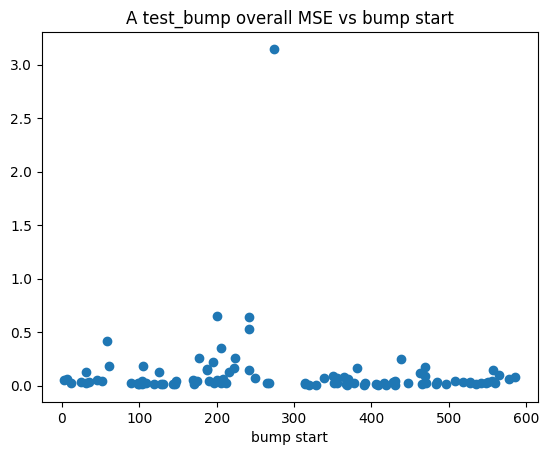

In [84]:
# select highest error
# visualize plot given a sim name
model_ver = 'A'
split = 'test_bump'
mse_table_path = BASE_DIR / 'evaluation' / f'{model_ver}_{split}_mse.csv'
df = pd.read_csv(mse_table_path).drop(columns=['Unnamed: 0'])
df['overall_mse_norm'] = (df['x-vel_mse_norm']+df['y-vel_mse_norm']+df['pressure_mse_norm']+df['turbulent_viscosity_mse_norm'])/4.0
df['bump_start'] = df['sim_name'].apply(lambda x: float(x.split('_')[1].split('-')[0]))
df['bump_width'] = df['sim_name'].apply(lambda x: float(x.split('_')[1].split('-')[1]))
df['bump_scale'] = df['sim_name'].apply(lambda x: float(x.split('_')[1].split('-')[2]))

bump_start_sorted = df[['bump_start','overall_mse_norm']].sort_values(by=['bump_start']).reset_index(drop=True)
plt.scatter(bump_start_sorted['bump_start'], bump_start_sorted['overall_mse_norm'])
plt.xlabel('bump start')
plt.title(f'{model_ver} test_bump overall MSE vs bump start')

Text(0.5, 1.0, 'A test_bump overall MSE vs bump width')

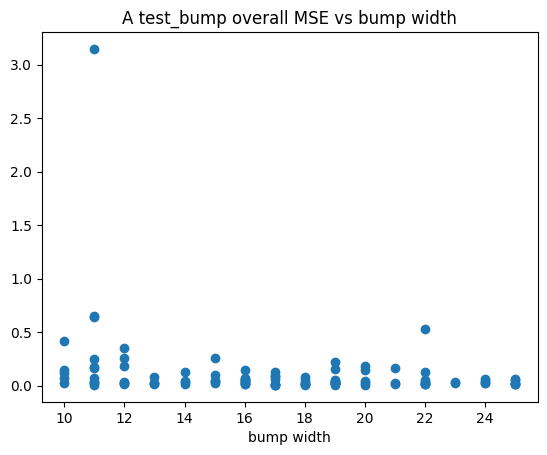

In [85]:
bump_width_sorted = df[['bump_width','overall_mse_norm']].sort_values(by=['bump_width']).reset_index(drop=True)
plt.scatter(bump_width_sorted['bump_width'], bump_width_sorted['overall_mse_norm'])
plt.xlabel('bump width')
plt.title(f'{model_ver} test_bump overall MSE vs bump width')

Text(0.5, 1.0, 'A test_bump overall MSE vs bump scale')

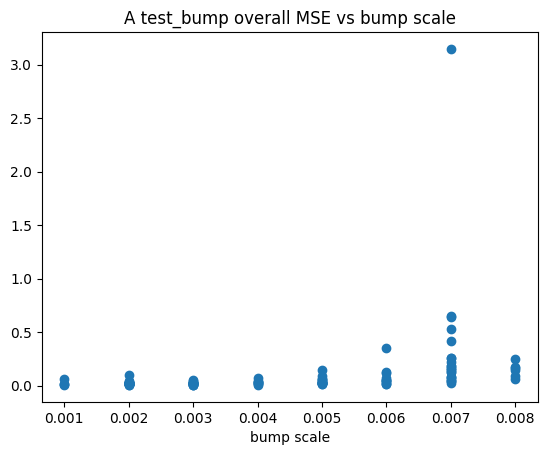

In [86]:
bump_scale_sorted = df[['bump_scale','overall_mse_norm']].sort_values(by=['bump_scale']).reset_index(drop=True)
plt.scatter(bump_scale_sorted['bump_scale'], bump_scale_sorted['overall_mse_norm'])
plt.xlabel('bump scale')
plt.title(f'{model_ver} test_bump overall MSE vs bump scale')

# Visualize Predictions

-40.5573 159.12479


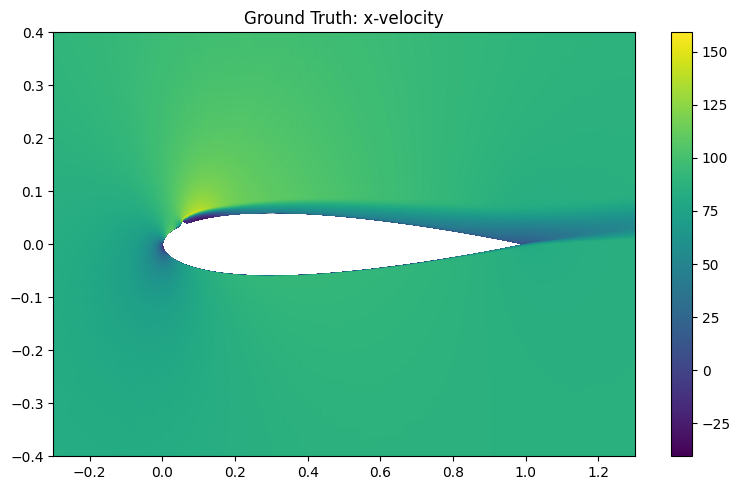

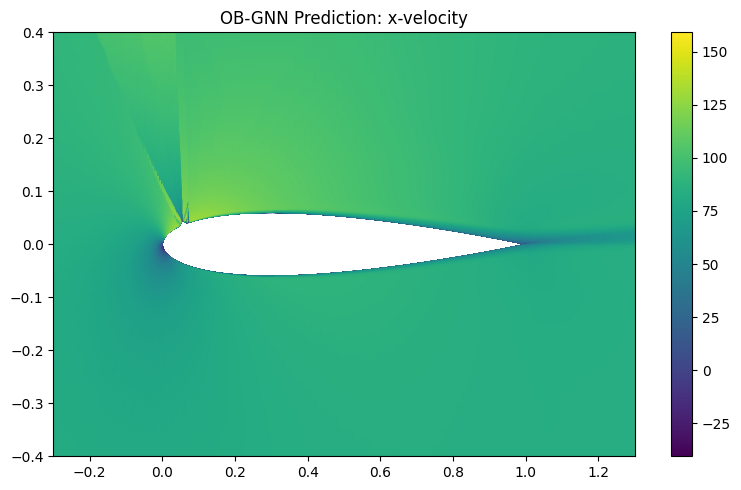

In [6]:
# load gt sample
import matplotlib.tri as mtri
FIELD_TO_COL = {
    "x-velocity": 0,
    "y-velocity": 1,
    "pressure": 2,
    "turbulent_viscosity": 3,
}
def make_plot(data, triang, title, target_sim_name, field, cmin, cmax):
    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.tripcolor(triang, data, shading="gouraud", vmin=cmin, vmax=cmax)
    # ax.set_title(f'{title} {target_sim_name} {field}')
    ax.set_title(f'{title} {field}')
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-0.4, 0.4)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

def visualize_bump_simulation(model_ver, target_sim_name, dataset_dir='bumped_dataset', field='x-velocity', cmin=None, cmax=None, pred_dir = None):
    # get mesh data
    bumped_dir = BASE_DIR /'airfrans_data' / dataset_dir
    bump_data = np.load(os.path.join(bumped_dir, (target_sim_name+'.npz')), allow_pickle=True)
    cells = bump_data['cells']
    x = bump_data['x-position']
    y = bump_data['y-position']
    triangles = np.vstack([cells[:, [0, 1, 2]], 
                        cells[:, [0, 2, 3]]])
    triang = mtri.Triangulation(x, y, triangles)
    # get ground truth data
    gt = bump_data[f"gt_{field.replace('-','_')}"]
    # get prediction data
    pred_dir = BASE_DIR / 'predictions' / model_ver / 'test_bump' if pred_dir is None else pred_dir
    pred_path = os.path.join(pred_dir, f"pred_{target_sim_name}.pt")
    pred_tensor = torch.load(pred_path, map_location="cpu")
    if isinstance(pred_tensor, torch.Tensor):
        pred_tensor = pred_tensor.numpy()

    pred = pred_tensor[:, FIELD_TO_COL[field]]

    cmin = min(gt.min(), pred.min()) if cmin is None else cmin
    cmax = max(gt.max(), pred.max()) if cmax is None else cmax
    print(cmin, cmax)
    make_plot(gt, triang, "Ground Truth:", target_sim_name, field, cmin, cmax)
    # make_plot(pred, triang, f"{model_ver} pred", target_sim_name, field, cmin, cmax)
    make_plot(pred, triang, "OB-GNN Prediction:", target_sim_name, field, cmin, cmax)


# visualize_bump_simulation('O', 'bump_131-25-0.006_87.639_5.000_0_0_12')
visualize_bump_simulation('O', 'bump_274-11-0.007_87.639_5.000_0_0_12')

# Plotting Training Loss

In [6]:
def plot_losses(model_version, loss_dict):
    train_loss = loss_dict['train']
    test_loss = loss_dict['test'] 
    ood_loss = loss_dict['ood']
    epochs = range(len(train_loss))

    fig, ax1 = plt.subplots(figsize=(8, 5))
    color1 = 'tab:blue'
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Training Loss', color=color1)
    line1 = ax1.plot(epochs, train_loss, color=color1, label='Train Loss')
    ax1.tick_params(axis='y', labelcolor=color1)

    ax2 = ax1.twinx()
    color2 = 'tab:red'
    color3 = 'tab:green'
    ax2.set_ylabel('Test Loss', color='black')
    line2 = ax2.plot(epochs, test_loss, color=color2, label='Test Loss', linestyle='--')
    line3 = ax2.plot(epochs, ood_loss, color=color3, label='Test OOD Loss', linestyle='-.')
    ax2.tick_params(axis='y', labelcolor='black')

    plt.title(f'{model_version} Training Loss over Epochs')
    fig.tight_layout() 
    fig.legend()
    plt.show()

## Experiment 0-1
experiment 0: training with identical compute (12 epochs)

experiment 1: training for longer epochs

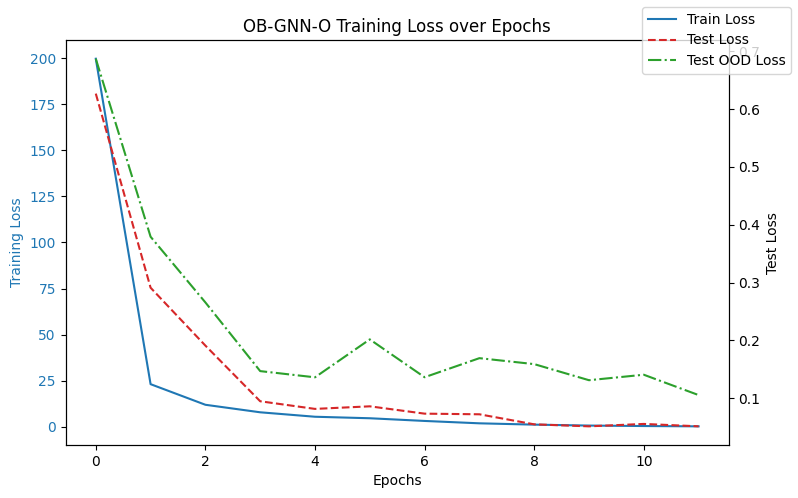

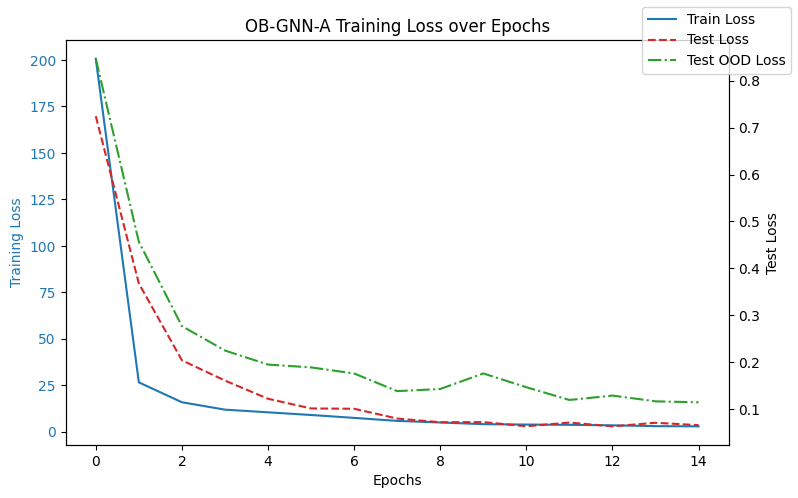

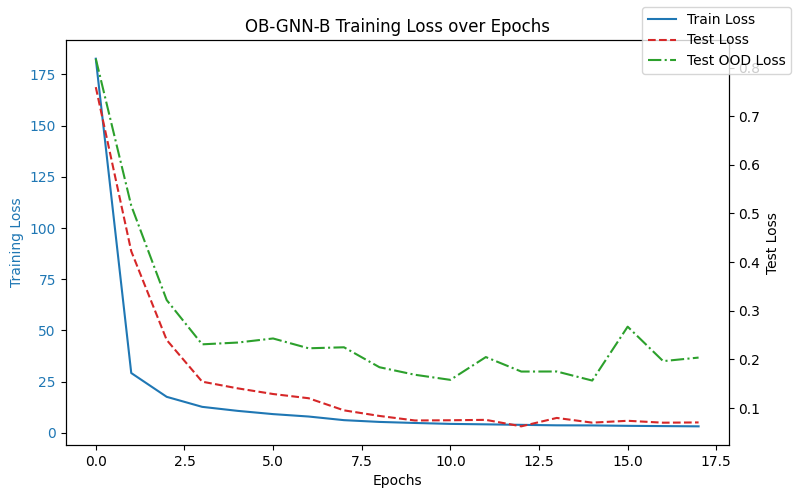

In [7]:
# og
O_loss_dict = {
    'train': [199.6106, 23.1875, 12.0177, 7.9404, 5.5274,4.7111, 3.2516, 1.9648, 1.2519, 0.7447, 0.4922, 0.3260],
    'test': [0.62676841543605, 0.29122133483949875, 0.1911431114059805, 0.09491177812366691, 0.08172645196565334,
               0.08616759669997834, 0.07350297047701103, 0.07240596249551567,  0.055036892812230336,  0.0515690210725594, 
               0.05573227268255112, 0.0516005822993963 ],
    'ood': [0.68709825156935, 0.37932465294536377, 0.2657856576095354, 0.14705407542996848, 0.13631661753139354,
              0.20190226148493243, 0.136456008790838,  0.1694272987371841, 0.15914196369318379, 0.13131955233926804, 
              0.1407945253176997,0.1056267608524553 ]
}

A_loss_dict = {
    'train':[200.6980, 26.6324, 15.9466, 11.9657, 10.5300, 9.0856,7.5347, 5.9153, 5.0543, 4.1545, 3.9427, 3.8003,
             3.5285, 3.0955, 2.9853],
    'test':[0.7244558545532606, 0.3676722396584536, 0.2038054292071734, 0.1605696997648438, 0.12177478581272214, 
            0.10107594388012854, 0.10042756964878136, 0.0795487707098391, 0.07168440756369505, 0.07198220566655232, 
            0.06306255436101496,0.0709618092175351, 0.06292925224892351, 0.07053721479035371,  0.0654391860527708 ],
    'ood':[0.8470585755757148, 0.4565718387136396,0.27665937844885896, 0.22467244154964852, 0.19466298892600647,
            0.18865410702315388, 0.17568661986745351, 0.1380571834496315, 0.14258978978440856, 0.17573689711311005, 
            0.14636893057270556, 0.11918176637826772,  0.12854942202025296, 0.11624733421532128, 0.11418002350440878]
}

B_loss_dict = {
    'train':[182.6484, 29.2359, 17.6168, 12.7292, 10.7710,9.1826, 8.0093, 6.2320, 5.3730, 4.8604, 4.4112,4.1899, 3.9413,
             3.7121, 3.6677, 3.4653, 3.3328, 3.2161],
    'test':[0.7599349853810885, 0.42233429641913106, 0.23978026892175738, 0.15404843504460441, 0.14034576277365748, 
            0.1286582685513607, 0.11999905214256404, 0.0950571105920321, 0.08355114597901209, 0.0742440436356115,
            0.0746803552973152,0.07550792308487245, 0.062164989879835916,0.07947068050849122, 0.06979518186375006,
            0.07358716903192712, 0.06967664254668927, 0.07021502431309382 ],
    'ood':[0.8183887316691165, 0.5160963440572979, 0.3218937090887929, 0.23084936300847705, 0.23452471611120843,
            0.2429024866035837, 0.2227310800049084, 0.22478610279642983, 0.18374279819872996,0.16826888712875496,
            0.15777885695512325,0.20465988720094921, 0.1748617236064562, 0.17499842102460514, 0.15634371994050922,
            0.2671840028676963, 0.19631492114619703, 0.20360152177907379],
}

C_loss_dict = {
    'train':[],
    'test':[],
    'ood':[],
}

plot_losses("OB-GNN-O",O_loss_dict)
plot_losses("OB-GNN-A",A_loss_dict)
plot_losses("OB-GNN-B",B_loss_dict)

## Experiment 2
experiment 2: training with longer epochs + delayed lr start epoch

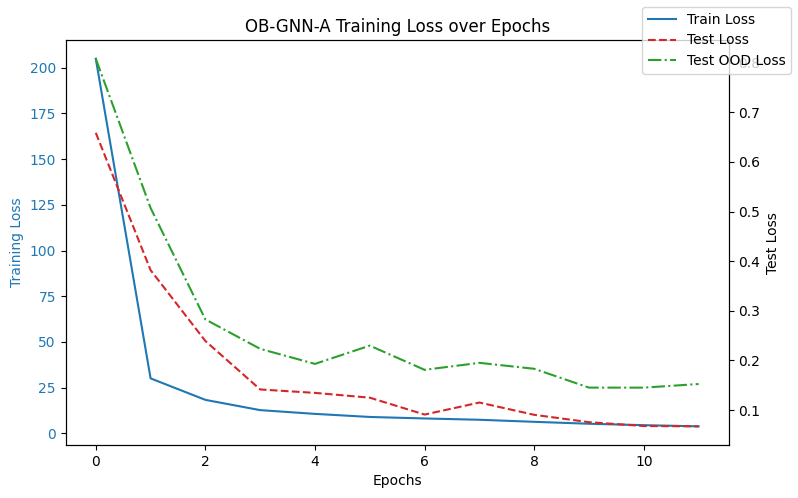

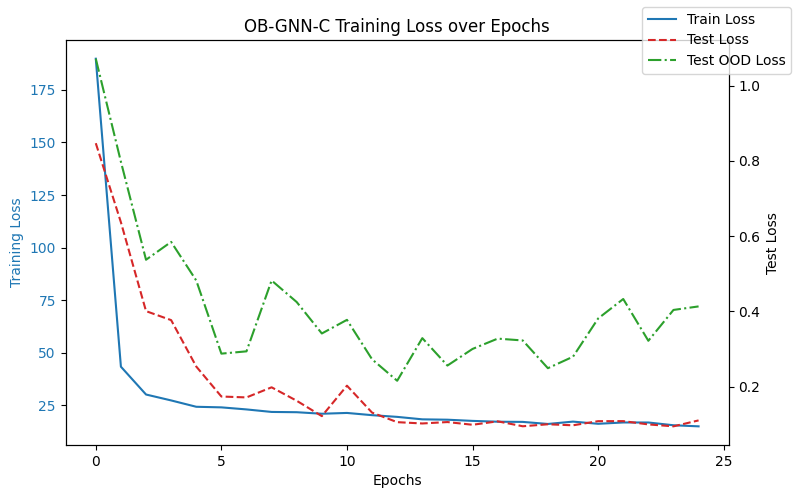

In [13]:
A_loss_dict = {
    'train':[204.9504, 30.0414, 18.2793, 12.6649, 10.6172, 8.9298, 8.1072, 7.3965, 6.2710, 5.2140, 
             4.4358, 3.7972],
    'test':[0.6585998987125246, 0.38200007842866, 0.23928273592563654, 0.1416589744290374, 0.134774515985061, 
            0.12511593892874306, 0.09109946061542493, 0.11530551510486776, 0.09059404496670953, 0.07576721254119415,
            0.06802208114736127, 0.067369989285998, ],
    'ood':[0.8078960678632686, 0.5071231859014523, 0.2827289876657606,  0.2234473605424363, 0.1931725725630261,
           0.2299357120268392, 0.1811938572255586, 0.1952761777781493,  0.18331252904423814, 0.14538619710465536,
            0.14532823753327329,  0.1526127608974051],
}

B_loss_dict = {
    'train':[],
    'test':[],
    'ood':[],
}


C_loss_dict = {
    'train':[189.8183, 43.3172, 30.0840, 27.2678, 24.2503,23.9692, 22.9903, 21.7931, 21.6632, 20.9359,
             21.3179, 20.2580, 19.4450, 18.2746, 18.0991,17.5349, 17.1474, 17.0560, 16.0727, 17.1924,
            16.1562, 16.7849, 16.7677, 15.4562, 14.9432  ],
    'test':[0.8468392834758127, 0.6367478389416309, 0.40069702094951215, 0.37681017638437003,0.25348878449556844,
             0.17384475625015253, 0.17145104982600307 , 0.1983037172070402, 0.16253110714602154 ,0.12173549036513891,
              0.20260320502697238, 0.13103759709424925 , 0.10573287403198663, 0.10224016670705072, 0.10599729823355643 ,
               0.09878261041957022, 0.1079183520613522, 0.0948137789347906,  0.10011001487589435, 0.09736543559524792,
                0.10833567239048071, 0.10845247397063584, 0.09976084414400802, 0.09461004972852619, 0.11037381486782175,  ],
    'ood':[1.0712993214067243, 0.7975767243974257, 0.5371852282262006, 0.5846431039224397, 0.482071376596855,
           0.2877635308942258,0.29385602015335827 ,  0.4821141047884297, 0.42477065428400673, 0.34131070344850717,
            0.3775309165878012, 0.27268545228420504,  0.215695837130215 , 0.3289838669118502, 0.25610464880403305,
            0.3002460932001373, 0.32764296088096323,0.3227511351521047, 0.24907394360430193, 0.27957893107456483,
            0.38109203208459924,  0.43292221962320093,0.3219236770755803,0.4038568637426326, 0.41323339929249114  ],
}

plot_losses("OB-GNN-A",A_loss_dict)
plot_losses("OB-GNN-C",C_loss_dict)

# Validation Analysis

In [185]:
def get_val_df(ver, model):
    val_dir = BASE_DIR / f'evaluation/{ver}_val' 
    csv_path = val_dir / f'{model}_{ver}_val_all_epochs_mse.csv'

    val_df = pd.read_csv(csv_path)
    val_df['overall_mse_norm'] = (val_df['x-vel_mse_norm'] + val_df['y-vel_mse_norm'] + val_df['pressure_mse_norm'] + val_df['turbulent_viscosity_mse_norm']) / 4.0
    mse_norm_columns = ['model_version','overall_mse_norm','x-vel_mse_norm', 'y-vel_mse_norm', 'pressure_mse_norm', 'turbulent_viscosity_mse_norm']
    print("Min overall val MSE:")
    display(val_df.loc[val_df['overall_mse_norm'].idxmin()].to_frame().T[mse_norm_columns])
    return val_df

def plot_overall_mse(model, ver, val_df):
    plt.plot(range(len(val_df)), val_df['overall_mse_norm'].to_list())
    plt.title(f'{model}_{ver} Overall Normalized MSE vs Epochs')
    plt.show()

def plot_field_losses(model, ver, val_df):
    x_vel_mse = val_df['x-vel_mse_norm'].to_list()
    y_vel_mse = val_df['y-vel_mse_norm'].to_list()
    pres_mse = val_df['pressure_mse_norm'].to_list()
    turb_mse = val_df['turbulent_viscosity_mse_norm'].to_list()
    
    epochs = range(len(val_df))

    fig, ax1 = plt.subplots(figsize=(8, 5))
    color1 = 'tab:blue'
    color2 = 'tab:red'
    color3 = 'tab:green'
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Normalized MSE', color='black')
    line1 = ax1.plot(epochs, x_vel_mse, color=color1, label='x-velocity')
    line2 = ax1.plot(epochs, y_vel_mse, color=color2, label='y-velocity')
    line3 = ax1.plot(epochs, pres_mse, color=color3, label='pressure')
    ax1.tick_params(axis='y', labelcolor='black')

    ax2 = ax1.twinx()
    color4 = 'tab:purple'
    ax2.set_ylabel('Normalized MSE', color='purple')
    line4 = ax2.plot(epochs, turb_mse, color=color4, label='turbulent viscosity', linestyle='-.')
    ax2.tick_params(axis='y', labelcolor='purple')

    plt.title(f'{model}_{ver} Val Bump MSE vs Epochs')
    fig.tight_layout() 
    fig.legend()
    plt.show()

Min overall val MSE:


,model_version,overall_mse_norm,x-vel_mse_norm,y-vel_mse_norm,pressure_mse_norm,turbulent_viscosity_mse_norm
19,A_v2_ep0019,0.036249,0.013616,0.001259,0.003646,0.126474


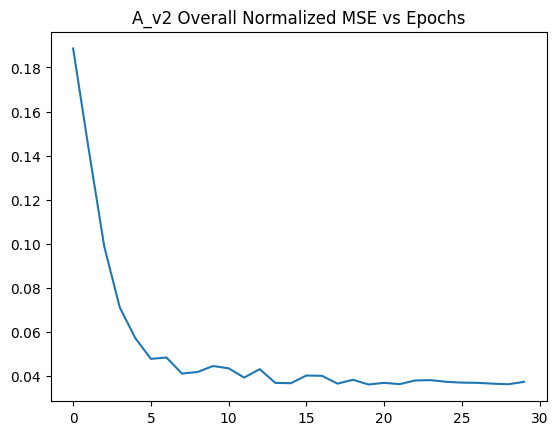

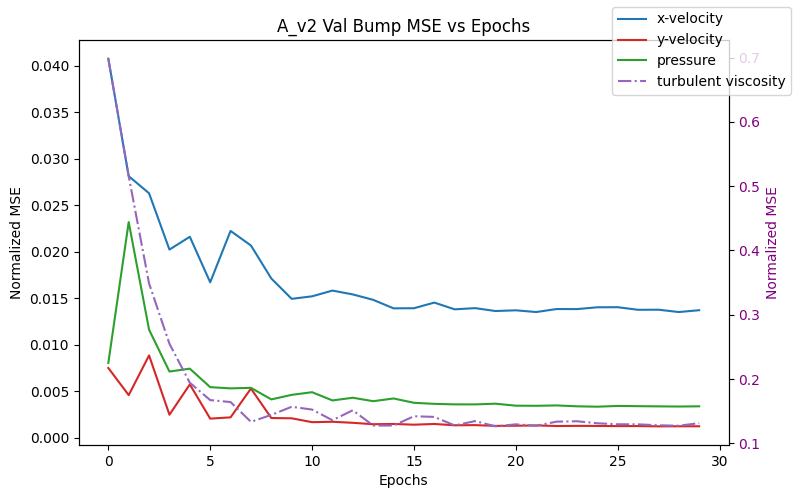

In [4]:
ver = 'v2'
model = 'A'

val_df = get_val_df(ver, model)
plot_overall_mse(model, ver, val_df)
plot_field_losses(model, ver, val_df)

Min overall val MSE:


,model_version,overall_mse_norm,x-vel_mse_norm,y-vel_mse_norm,pressure_mse_norm,turbulent_viscosity_mse_norm
14,B_v1_ep0014,0.035882,0.013577,0.00127,0.002972,0.125708


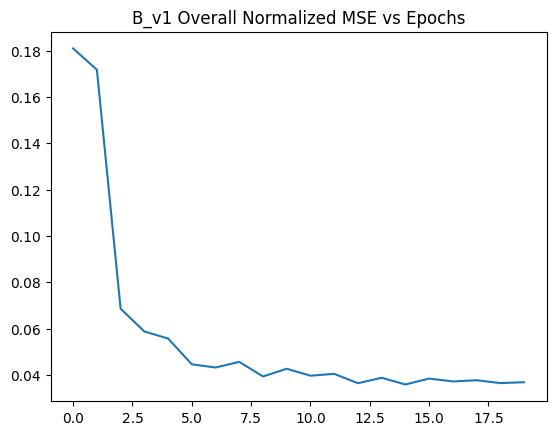

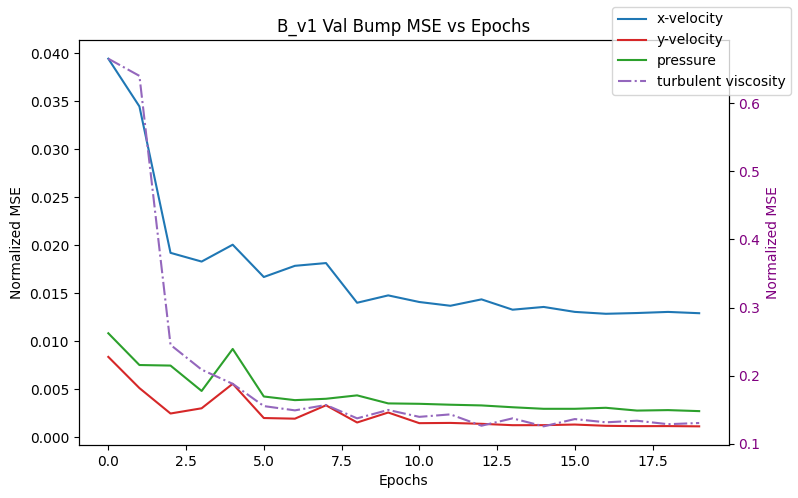

In [45]:
ver = 'v1'
model = 'B'

val_df = get_val_df(ver, model)
plot_overall_mse(model, ver, val_df)
plot_field_losses(model, ver, val_df)

Min overall val MSE:


,model_version,overall_mse_norm,x-vel_mse_norm,y-vel_mse_norm,pressure_mse_norm,turbulent_viscosity_mse_norm
17,C_v1_ep0017,0.115317,0.013538,0.001384,0.003063,0.443283


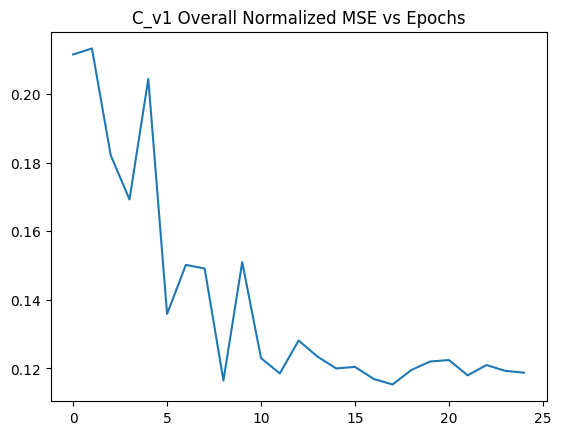

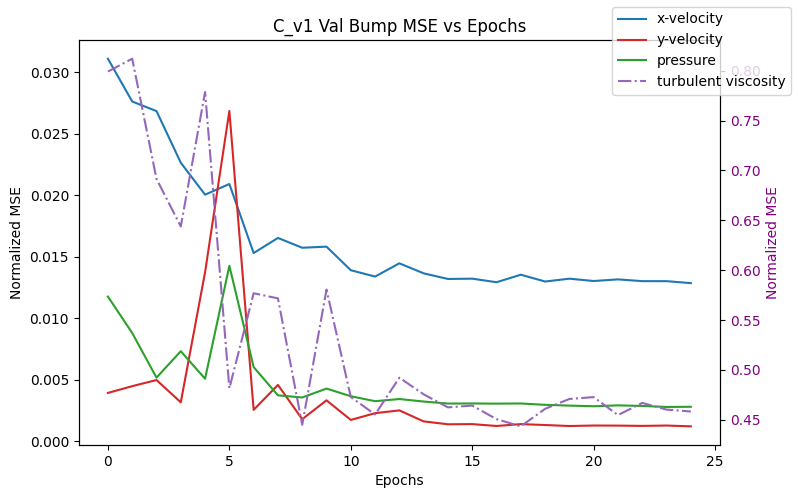

In [47]:
ver = 'v1'
model = 'C'

val_df = get_val_df(ver, model)
plot_overall_mse(model, ver, val_df)
plot_field_losses(model, ver, val_df)

# Surface Metric Validation

In [220]:
surface_metrics = ['H','cp','cf','s_gen']
metrics = ['H','cp','cf','s_gen','C_D','cls','cds']

def compute_global_stats(df, target_fields):
    stats = {}
    for key in target_fields:
        data = df[key]  # shape (total_nodes,)
        stats[key] = {
            'mean': np.mean(data),
            'std': np.std(data)
        }
    return stats

def get_gt_node_stats():
    gt_df = pd.read_csv(BASE_DIR/'surface_stats'/'bumped_gt'/'bumped_gt_node_stats.csv', index_col=False)
    gt_df.drop(columns=['Unnamed: 0'], inplace=True)
    gt_df['node_id'] = gt_df['sim_id'] + ',' + gt_df['x'].astype(str) + ',' + gt_df['y'].astype(str)
    return gt_df


def get_mse_table(pred_df_path, gt_df, surface_metrics):
    pred_df = pd.read_csv(pred_df_path)
    # pred_df.drop(columns=['Unnamed: 0'], inplace=True)
    pred_df['node_id'] = pred_df['sim_id'] + ',' + pred_df['x'].astype(str) + ',' + pred_df['y'].astype(str)

     # normalize
    gt_val_df = gt_df[gt_df['sim_id'].isin(pred_df['sim_id'].unique())]
    stats = compute_global_stats(gt_val_df, surface_metrics)

    # get mse norm per metric
    big_df = pd.merge(pred_df, gt_df[['node_id']+metrics], on='node_id', how='left', suffixes=('','_gt'))
    for col in surface_metrics:
        big_df[col+'_mse_norm'] = ((big_df[col+'_gt'] - big_df[col]) / stats[col]['std'])**2
        big_df[col+'_mse'] = (big_df[col+'_gt'] - big_df[col])**2

    metric_cols = [metric+'_mse' for metric in surface_metrics] + [metric+'_mse_norm' for metric in surface_metrics]
    mse_table = big_df.groupby('sim_id')[metric_cols].mean()
    return mse_table

def get_surface_val_df(model_ver, surface_metrics):
    gt_df = get_gt_node_stats()
    val_rows = [] # surface metrics mse vs epoch
    pred_dir = BASE_DIR/'surface_stats'/f'{model_ver}_val'
    for epoch_stats_file in sorted(os.listdir(pred_dir)):
        if model_ver in ('S','D'):
            ep = int(epoch_stats_file.split('_')[1].removeprefix('ep'))
        else:
            ep = int(epoch_stats_file.split('_')[2].removeprefix('ep'))
        mse_table = get_mse_table(pred_dir / epoch_stats_file, gt_df, surface_metrics)
        overall_mse = mse_table.mean()
        overall_mse['epoch'] = ep
        val_rows.append(overall_mse)
    val_df = pd.DataFrame(val_rows)
    val_df.insert(0, 'epoch', val_df.pop('epoch'))
    val_df['overall_mse_norm'] = (val_df['H_mse_norm'] + val_df['cp_mse_norm'] + val_df['cf_mse_norm'] + val_df['s_gen_mse_norm']) / 4.0
    print("Min overall val MSE:")
    display(val_df.loc[val_df['overall_mse_norm'].idxmin()].to_frame().T[['epoch', 'overall_mse_norm'] + [metric+'_mse_norm' for metric in surface_metrics]])
    return val_df

def plot_overall_mse(model_ver, val_df):
    fig, ax = plt.subplots(figsize=(8, 5))
    min_table = val_df.loc[val_df['overall_mse_norm'].idxmin()].to_frame().T[['epoch', 'overall_mse_norm']]
    ax.plot(range(len(val_df)), val_df['overall_mse_norm'].to_list())
    plt.axhline(y=min_table['overall_mse_norm'].item(), color='r', linestyle='dotted')
    plt.scatter(min_table['epoch'], min_table['overall_mse_norm'], color='r')
    plt.title(f'{model_ver} Overall Normalized MSE vs Epochs')
    plt.show()

def plot_surface_field_losses(model_ver, val_df):
    H_mse = val_df['H_mse_norm'].to_list()
    cp_mse = val_df['cp_mse_norm'].to_list()
    cf_mse = val_df['cf_mse_norm'].to_list()
    s_gen_mse = val_df['s_gen_mse_norm'].to_list()
    overall_mse = val_df['overall_mse_norm']
    epochs = range(len(val_df))

    fig, ax1 = plt.subplots(figsize=(8, 5))
    color1 = 'tab:red'
    color2 = 'tab:orange'
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Normalized MSE', color='red')
    line1 = ax1.plot(epochs, cp_mse, color=color1, label='cp', linestyle='dotted')
    line2 = ax1.plot(epochs, cf_mse, color=color2, label='cf', linestyle='dotted')
    ax1.tick_params(axis='y', labelcolor='red')

    ax2 = ax1.twinx()
    color3 = 'tab:blue'
    color4 = 'tab:green'
    color5 = 'tab:purple'
    ax2.set_ylabel('Normalized MSE', color='blue')
    line3 = ax2.plot(epochs, H_mse, color=color3, label='H', linestyle='-.')
    line4 = ax2.plot(epochs, s_gen_mse, color=color4, label='s_gen', linestyle='-.')
    line5 = ax2.plot(epochs, overall_mse, color=color5, label='overall')
    ax2.tick_params(axis='y', labelcolor='blue')

    plt.title(f'{model_ver} Val Bump Surface Metric MSE vs Epochs')
    fig.tight_layout() 
    fig.legend()
    plt.show()

def plot_overall_val_score(model_ver, val_df, sur_val_df):
    val_df['epoch'] = val_df['model_version'].apply(lambda x: int(x.split('_')[-1].removeprefix('ep')))
    big_df = pd.merge(val_df, sur_val_df[['epoch','overall_mse_norm']+[metric+"_mse_norm" for metric in surface_metrics]], on='epoch', how='left', suffixes=('', '_surface'))
    big_df['overall_score'] = (big_df['overall_mse_norm'] + big_df['overall_mse_norm_surface'])/2.0
    fig, ax1 = plt.subplots(figsize=(8, 5))
    min_table = big_df.loc[big_df['overall_score'].idxmin()].to_frame().T[['epoch', 'overall_score']]
    display(min_table)
    ax1.plot(range(len(big_df)), big_df['overall_score'].to_list(), color='tab:purple',  label='overall score')
    ax1.plot(range(len(big_df)), big_df['overall_mse_norm_surface'].to_list(), color='tab:green', label='surface overall mse', linestyle='-.')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Normalized MSE', color='black')

    ax2 = ax1.twinx()
    ax2.plot(range(len(big_df)), big_df['overall_mse_norm'].to_list(), color='tab:blue',  label='field overall mse', linestyle='-.')
    ax2.set_ylabel('Normalized MSE', color='tab:blue')

    ax1.axhline(y=min_table['overall_score'].item(), color='r', linestyle='dotted')
    ax1.scatter(min_table['epoch'], min_table['overall_score'], color='r')
    fig.tight_layout() 
    fig.legend()
    plt.title(f'{model_ver} Overall Normalized MSE vs Epochs')
    plt.show()

Min overall val MSE:


,model_version,overall_mse_norm,x-vel_mse_norm,y-vel_mse_norm,pressure_mse_norm,turbulent_viscosity_mse_norm
18,A_v1_ep0018,0.03563,0.01362,0.001467,0.003384,0.124047


Min overall val MSE:


,epoch,overall_mse_norm,H_mse_norm,cp_mse_norm,cf_mse_norm,s_gen_mse_norm
9,9.0,1.777067,1.145873,1.345734,1.615601,3.001061


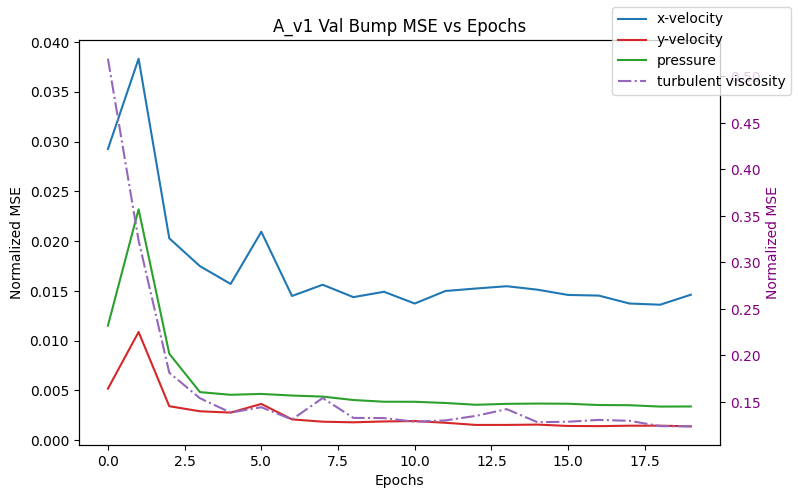

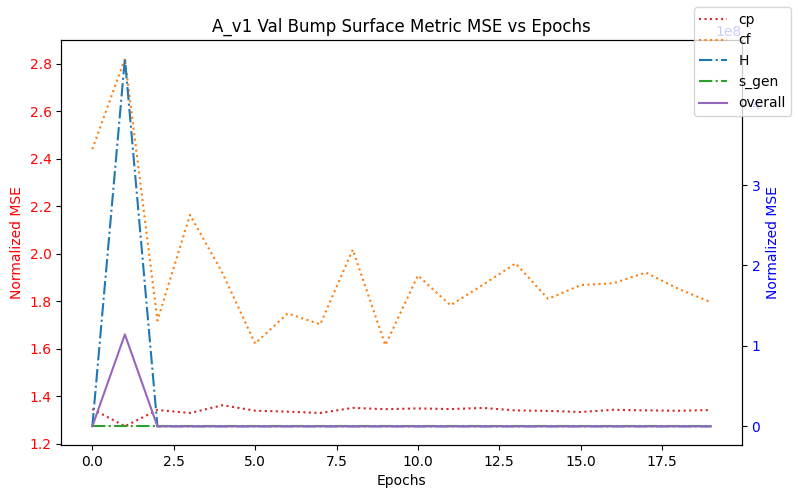

,epoch,overall_score
9,9,0.907705


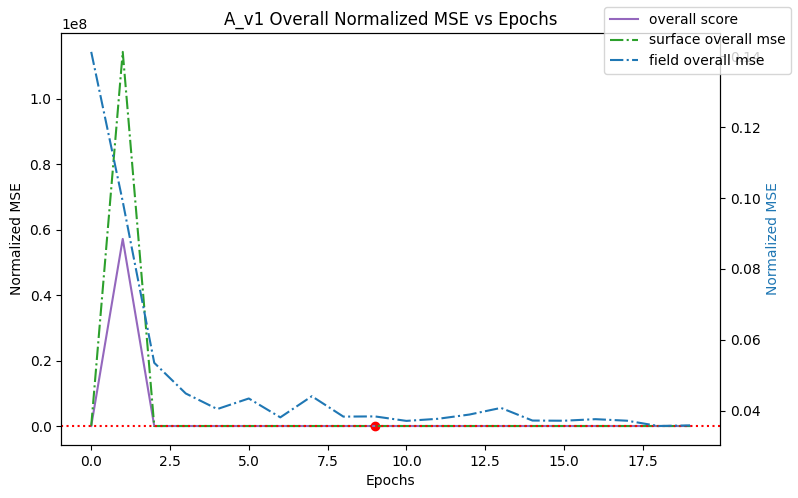

In [198]:
model = 'A'
ver = 'v1'
model_ver = model + '_' + ver

val_df = get_val_df(ver, model)
sur_val_df = get_surface_val_df(model_ver, surface_metrics)
plot_field_losses(model, ver, val_df)
plot_surface_field_losses(model_ver, sur_val_df)
plot_overall_val_score(model_ver, val_df, sur_val_df)